## Customer Churn Prediction Using Artificial Neural Networks

#### Business problem:

#### Predict whether a telecom customer will churn (leave) or stay, based on their customer and service information.

### Step 1: Import the Data

In [1]:
import pandas as pd

df = pd.read_csv("D:\Innomatics_2\ANN\project\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 2:Understand the Data

In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


### Step 3 — Check missing values

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Missing Value Observation: The dataset contains no null values according to df.isnull().sum(). Therefore, no direct null-value imputation is required at this stage.

### Step 4 — Check duplicate customers

In [4]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


#### Duplicate Value Observation: The dataset contains 0 duplicate rows, indicating that there are no completely duplicated customer records.

### Step 5 — Understand the target variable

In [5]:
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


#### Class Imbalance Observation: The target variable contains 5,174 non-churned customers (73.46%) and 1,869 churned customers (26.54%). This indicates a moderate class imbalance, with churned customers representing the minority class. Therefore, an appropriate imbalance-handling technique will be considered during model preparation.

### Step 6 — Basic statistical summary

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Statistical Observation: The average customer tenure is approximately 32.37 months, while the average monthly charge is approximately $64.76. Customer tenure ranges from 0 to 72 months, and monthly charges range from $18.25 to $118.75. The SeniorCitizen variable has a mean of 0.162, indicating that approximately 16.2% of customers are senior citizens.

### Step 7 — Check TotalCharges

In [7]:
print("Unique blank/space values in TotalCharges:")
print((df["TotalCharges"].str.strip() == "").sum())

print("\nData type:")
print(df["TotalCharges"].dtype)

Unique blank/space values in TotalCharges:
11

Data type:
object


#### Data Quality Observation: The TotalCharges column was initially detected as an object data type. Further inspection identified 11 blank/space entries. These values will be handled during preprocessing before model training.

### Step 8 — Visual EDA: Churn distribution

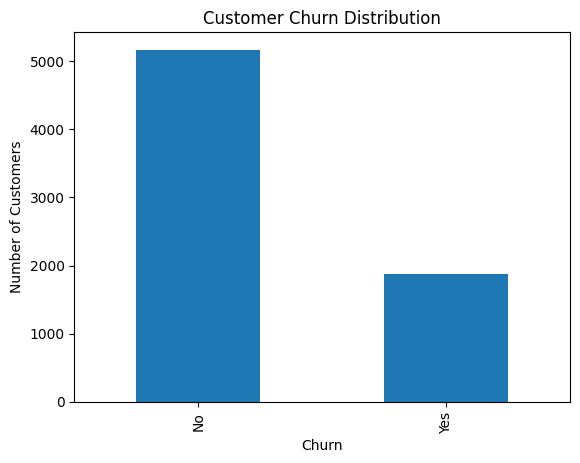

In [8]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Churn Distribution Observation: The bar chart shows that the majority of customers did not churn, while a smaller proportion churned. There are 5,174 non-churned customers compared with 1,869 churned customers, confirming moderate class imbalance in the target variable.

### Step 9 — Find which contract type has more churn

In [9]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


#### Contract Type Observation: Month-to-month customers show substantially higher churn than customers on one-year and two-year contracts. This suggests that contract duration is an important factor associated with customer churn. The company could consider retention offers or incentives to encourage month-to-month customers to adopt longer-term contracts.

### Step 10 — Let's visualize this finding

In [11]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn_rate)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


#### Contract and Churn Insight: Customers with month-to-month contracts have the highest churn rate at 42.71%, while one-year and two-year contract customers have much lower churn rates of 11.27% and 2.83%, respectively. This suggests that longer-term contracts are associated with greater customer retention.

### Step 11 — Create the visualization

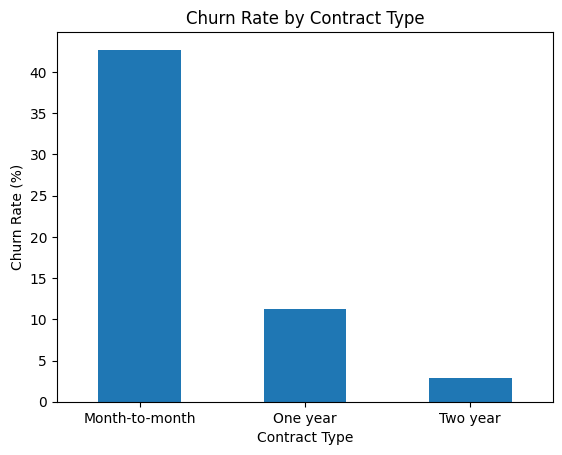

In [12]:
contract_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### Insight: Customers with month-to-month contracts have the highest churn rate, while customers with longer-term contracts have substantially lower churn. This indicates that contract type is an important factor associated with customer retention.

### Step 12 — Check churn by Internet Service

In [13]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn_rate)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


#### Internet Service Insight: Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service. This indicates that internet service type is an important factor associated with customer churn and may warrant further investigation.

### Step 13 — Visualize Internet Service churn

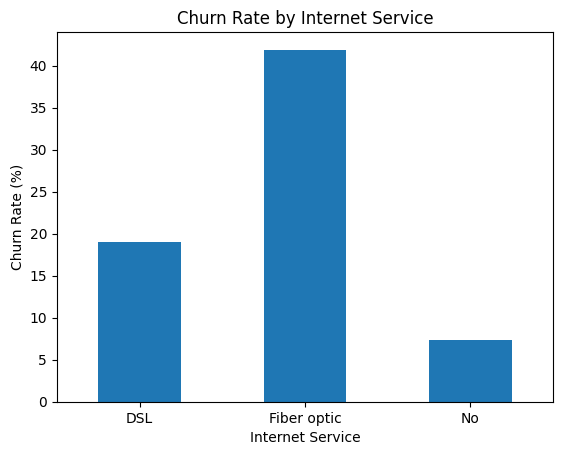

In [14]:
internet_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### The Internet Service chart clearly shows that Fiber optic customers have the highest churn rate (41.9%), followed by DSL (19.0%), while customers without internet service have the lowest (~7.4%).

### Step 14 — Tenure and churn

In [15]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

tenure_churn_rate = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn_rate)

Churn                No        Yes
TenureGroup                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


#### Tenure and Churn Insight: Customers with 0–12 months of tenure have the highest churn rate at 47.44%. The churn rate decreases as customer tenure increases, reaching 9.51% for customers with 49–72 months of tenure. This indicates that early-stage customers are at greater risk of leaving and should receive stronger onboarding and retention efforts.`

### Step 15 — Visualize tenure vs churn

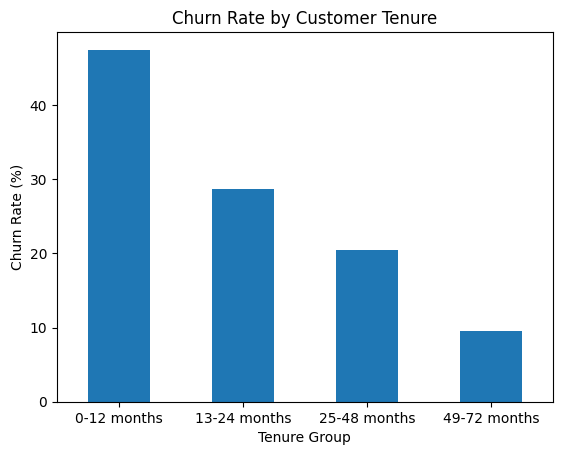

In [17]:
tenure_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

#### As customer tenure increases, the churn rate generally decreases. New customers are at the highest risk of leaving.

### Step 16 — Monthly Charges vs Churn

In [18]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

#### Monthly Charges Insight: The average monthly charge of churned customers is approximately $74.44, compared with $61.27 for customers who stayed. This indicates that customers with higher monthly charges may have a greater likelihood of churn.

### Step 17 — Visualize Monthly Charges vs Churn

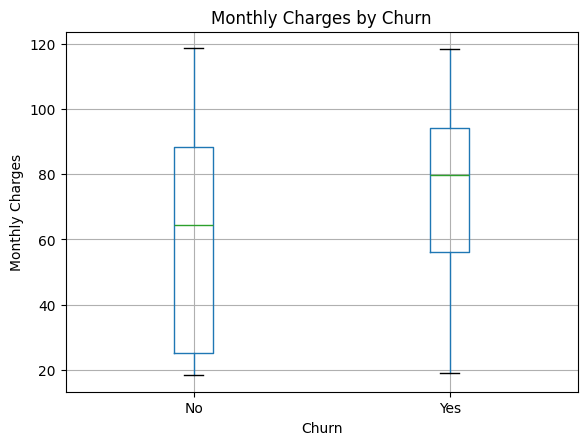

In [19]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Monthly Charges Insight: Churned customers generally have higher monthly charges than customers who stayed. However, the distributions overlap considerably, indicating that monthly charges alone may not be sufficient to predict churn and should be considered together with other customer and service characteristics.

### Step 18 — Payment Method

In [20]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn_rate)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


#### Payment Method Insight: Customers using electronic checks have the highest churn rate at 45.29%, while customers using automatic bank transfer and automatic credit card payments have substantially lower churn rates. This suggests that payment method is associated with customer churn and may be useful for identifying higher-risk customers.

### Step 19 — Create a summary of categorical columns

In [21]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

TotalCharges:
['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']

Churn:
['No' 'Yes']


### Step 20 — Start preprocessing

In [22]:
df_model = df.copy()

# Remove columns that should not be used for prediction
df_model = df_model.drop(columns=["customerID", "TenureGroup"])

# Convert TotalCharges to numeric
df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"],
    errors="coerce"
)

print("Shape after removing unnecessary columns:", df_model.shape)

print("\nMissing values after converting TotalCharges:")
print(df_model.isnull().sum())

Shape after removing unnecessary columns: (7043, 20)

Missing values after converting TotalCharges:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


### Step 21 — Remove the 11 invalid TotalCharges rows

In [23]:
df_model = df_model.dropna(subset=["TotalCharges"])

print("Shape after removing missing TotalCharges:", df_model.shape)
print("Missing values remaining:", df_model.isnull().sum().sum())

Shape after removing missing TotalCharges: (7032, 20)
Missing values remaining: 0


### Step 22 — Separate features and target

In [24]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (7032, 19)
Target shape: (7032,)

Target values:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


### Step 23 — Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (5625, 19)
Testing data: (1407, 19)

Training target distribution:
Churn
No     4130
Yes    1495
Name: count, dtype: int64

Testing target distribution:
Churn
No     1033
Yes     374
Name: count, dtype: int64


### Step 24 — Encode the categorical variables

### Step 24A — Identify categorical and numerical columns

In [26]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### Step 24B — Create the encoding + scaling pipeline

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (5625, 45)
Processed testing shape: (1407, 45)


### Step 25 — Apply SMOTE

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining shape after SMOTE:")
print(X_train_smote.shape)

Before SMOTE:
Churn
No     4130
Yes    1495
Name: count, dtype: int64

After SMOTE:
Churn
No     4130
Yes    4130
Name: count, dtype: int64

Training shape after SMOTE:
(8260, 45)


### Step 26 — Build the Vanilla ANN

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

ann_model = keras.Sequential([
    layers.Input(shape=(X_train_smote.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

### Step 27 — Train the Vanilla ANN

In [32]:
# Convert target labels from text to numbers

y_train_smote = y_train_smote.map({
    "No": 0,
    "Yes": 1
})

y_test = y_test.map({
    "No": 0,
    "Yes": 1
})

print("Training target dtype:", y_train_smote.dtype)
print("Testing target dtype:", y_test.dtype)

print("\nTraining target values:")
print(y_train_smote.value_counts())

Training target dtype: int64
Testing target dtype: int64

Training target values:
Churn
0    4130
1    4130
Name: count, dtype: int64


In [33]:
ann_history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7479 - loss: 0.5100 - val_accuracy: 0.6992 - val_loss: 0.6440
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7830 - loss: 0.4581 - val_accuracy: 0.6992 - val_loss: 0.6370
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7848 - loss: 0.4515 - val_accuracy: 0.7040 - val_loss: 0.6286
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7887 - loss: 0.4468 - val_accuracy: 0.7119 - val_loss: 0.6203
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7904 - loss: 0.4430 - val_accuracy: 0.7167 - val_loss: 0.6145
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7919 - loss: 0.4396 - val_accuracy: 0.7197 - val_loss: 0.6057
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7936 - loss: 0.4366 - val_accuracy: 0.7264 - val_loss: 0.5942
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7966 - loss: 0.4340 - val_accuracy: 0.

### Step 28 — Visualize ANN learning curves

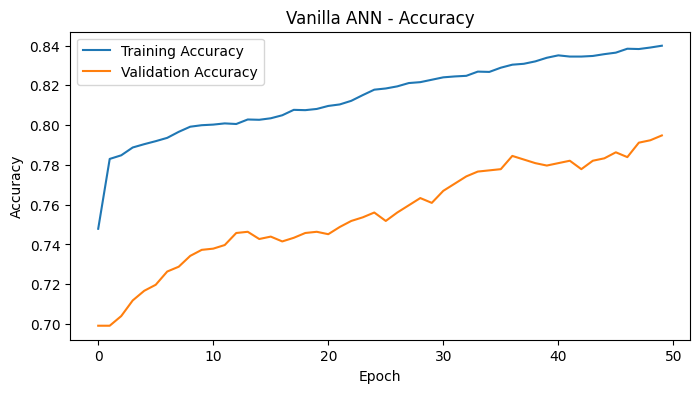

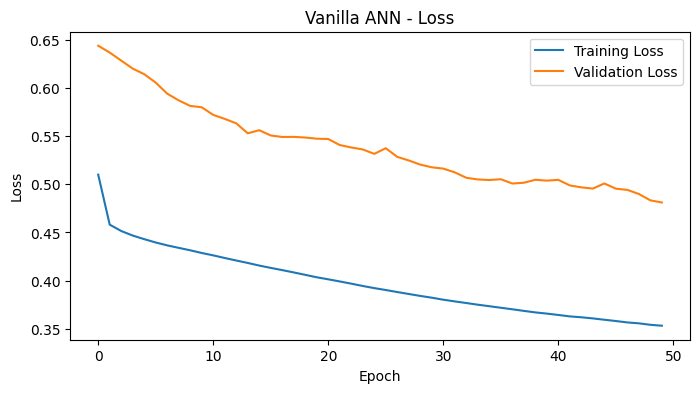

In [34]:
import matplotlib.pyplot as plt

# Accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(ann_history.history["accuracy"], label="Training Accuracy")
plt.plot(ann_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Vanilla ANN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(ann_history.history["loss"], label="Training Loss")
plt.plot(ann_history.history["val_loss"], label="Validation Loss")
plt.title("Vanilla ANN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Vanilla ANN Training Observation: The Vanilla ANN showed steady learning during training. Training accuracy increased from approximately 75% to 84%, while validation accuracy improved from approximately 70% to 79.5%. At the same time, both training and validation loss decreased throughout training. The difference between training and validation performance indicates some generalization gap, but there is no strong evidence of severe overfitting. Overall, the Vanilla ANN learned useful patterns for predicting customer churn.

### Test the Vanilla ANN

In [35]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Vanilla ANN Test Accuracy: {ann_test_accuracy:.4f}")
print(f"Vanilla ANN Test Loss: {ann_test_loss:.4f}")

Vanilla ANN Test Accuracy: 0.7740
Vanilla ANN Test Loss: 0.4928


#### Vanilla ANN Test Observation: The Vanilla ANN achieved a test accuracy of 77.40% with a test loss of 0.4928. The test performance is slightly lower than the validation accuracy of approximately 79.48%, indicating a small generalization gap. Overall, the model provides a reasonable baseline for customer churn prediction.

### Precision, Recall, F1-score & Confusion Matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.77      0.77      1407


Confusion Matrix:
[[870 163]
 [155 219]]


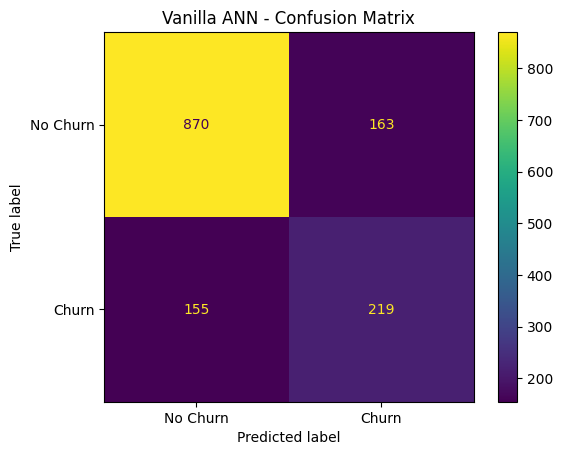

In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = ann_model.predict(X_test_processed)

# Convert probabilities to Yes/No predictions
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Vanilla ANN - Confusion Matrix")
plt.show()

#### Vanilla ANN Evaluation Observation: The Vanilla ANN achieved an overall test accuracy of approximately 77%. The model performed better in predicting customers who did not churn, with a precision of 0.85 and recall of 0.84. However, performance for churned customers was lower, with a precision of 0.57, recall of 0.59, and F1-score of 0.58. The confusion matrix shows 219 correctly identified churned customers and 155 churned customers that were incorrectly classified as non-churned. This indicates that although the model provides a reasonable baseline, there is room for improvement in identifying customers at risk of churn.

### ROC-AUC

Vanilla ANN ROC-AUC: 0.8116


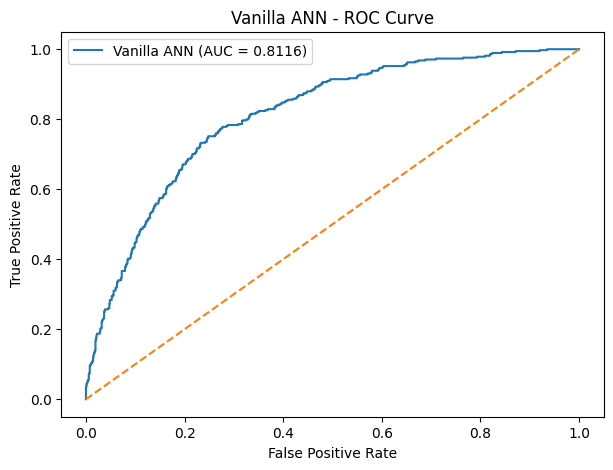

In [37]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Vanilla ANN ROC-AUC: {roc_auc:.4f}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Vanilla ANN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Vanilla ANN - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### ROC-AUC Observation: The Vanilla ANN achieved a ROC-AUC score of 0.8116, indicating good discriminatory ability between customers who churn and those who remain. The ROC curve lies substantially above the random classifier line, showing that the model can distinguish the two classes reasonably well across different classification thresholds.

### Step 25 — Install Keras Tuner

In [38]:
!pip install keras-tuner

  Using cached grpcio-1.83.1-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
Using cached grpcio-1.83.1-cp313-cp313-win_amd64.whl (5.2 MB)

   ------------- -------------------------- 1/3 [grpcio]
   ------------- -------------------------- 1/3 [grpcio]
   ------------- -------------------------- 1/3 [grpcio]
   ------------- -------------------------- 1/3 [grpcio]
   -------------------------- ------------- 2/3 [keras-tuner]
   -------------------------- ------------- 2/3 [keras-tuner]
   -------------------------- ------------- 2/3 [keras-tuner]
   -------------------------- ------------- 2/3 [keras-tuner]
   ---------------------------------------- 3/3 [keras-tuner]



### Step 26 — Build the Keras Tuner search space

In [40]:
import sys
!{sys.executable} -m pip install keras-tuner

  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.8-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)

   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]



In [42]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [43]:
def build_tuner_model(hp):

    model = keras.Sequential()

    # Input layer
    model.add(
        layers.Input(shape=(X_train_smote.shape[1],))
    )

    # Number of hidden layers
    num_layers = hp.Int(
        "num_layers",
        min_value=1,
        max_value=3,
        step=1
    )

    # Hidden layers
    for i in range(num_layers):

        units = hp.Int(
            f"units_{i}",
            min_value=16,
            max_value=64,
            step=16
        )

        model.add(
            layers.Dense(
                units=units,
                activation="relu"
            )
        )

    # Output layer
    model.add(
        layers.Dense(1, activation="sigmoid")
    )

    # Learning rate
    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.001, 0.0005, 0.0001]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Step 28 — Create the Keras Tuner

In [44]:
tuner = kt.RandomSearch(
    build_tuner_model,
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=1,
    directory="keras_tuner",
    project_name="telco_churn_ann"
)

tuner.search_space_summary()

Search space summary
Default search space size: 3
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


### Step 29 — Start the actual search

In [46]:
import sys
!{sys.executable} -m pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ------------------------ --------------- 3.4/5.5 MB 23.4 MB/s eta 0:00:01
   ---------------------------- ----------- 3.9/5.5 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------  5.5/5.5 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 8.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   -------------------- ------------------- 1/2 [tensorboard]
   ---------------------------------------- 2/2 [tensorboard]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [47]:
tuner.search(
    X_train_smote,
    y_train_smote,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Trial 10 Complete [00h 00m 42s]
val_accuracy: 0.7421307563781738

Best val_accuracy So Far: 0.8480629324913025
Total elapsed time: 00h 06m 38s


### Step 30 — Get the best hyperparameters

In [48]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best number of hidden layers:", best_hps.get("num_layers"))
print("Best learning rate:", best_hps.get("learning_rate"))

for i in range(best_hps.get("num_layers")):
    print(f"Best units in layer {i+1}:", best_hps.get(f"units_{i}"))

Best number of hidden layers: 3
Best learning rate: 0.0005
Best units in layer 1: 32
Best units in layer 2: 64
Best units in layer 3: 48


### Step 31 — Build the tuned ANN

In [49]:
# Build the final tuned ANN using the best hyperparameters

tuned_ann = keras.Sequential([
    layers.Input(shape=(X_train_smote.shape[1],)),
    
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(48, activation="relu"),
    
    layers.Dense(1, activation="sigmoid")
])

tuned_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tuned_ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 32)                  │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 48)                  │           3,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              49 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,753 (26.38 KB)

 Trainable params: 6,753 (26.38 KB)

 Non-trainable params: 0 (0.00 B)

#### The 45 input features come from our preprocessing/one-hot encoding. The tuner found that this deeper architecture performed better than our Vanilla ANN during validation.

### Step 32 — Train the Tuned ANN

In [50]:
tuned_history = tuned_ann.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7548 - loss: 0.4985 - val_accuracy: 0.7391 - val_loss: 0.6087
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7798 - loss: 0.4558 - val_accuracy: 0.7318 - val_loss: 0.5930
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7857 - loss: 0.4490 - val_accuracy: 0.7349 - val_loss: 0.5865
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7890 - loss: 0.4448 - val_accuracy: 0.7385 - val_loss: 0.5805
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7909 - loss: 0.4411 - val_accuracy: 0.7391 - val_loss: 0.5735
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7918 - loss: 0.4373 - val_accuracy: 0.7439 - val_loss: 0.5662
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7937 - loss: 0.4338 - val_accuracy: 0.7488 - val_loss: 0.5550
Epoch 8/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7956 - loss: 0.4302 - val_accuracy: 0.

#### Tuned ANN Training Observation: The tuned ANN showed steady improvement during training. Training accuracy reached approximately 85.6%, while validation accuracy reached approximately 86.9%. Both training and validation losses decreased throughout the training process. The validation performance remained strong and did not show a clear pattern of severe overfitting. Overall, the tuned architecture performed better during validation than the Vanilla ANN.

### Step 33 — Plot Tuned ANN learning curves

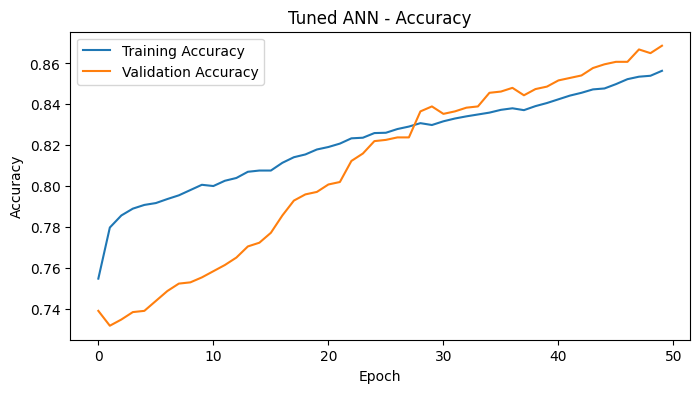

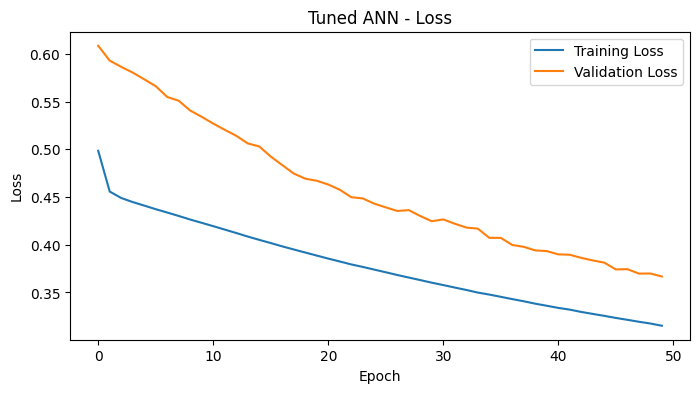

In [51]:
# Tuned ANN - Accuracy curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(
    tuned_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    tuned_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Tuned ANN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Tuned ANN - Loss curve

plt.figure(figsize=(8, 4))

plt.plot(
    tuned_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    tuned_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Tuned ANN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Tuned ANN Training Observation: The tuned ANN showed consistent learning throughout the 50 training epochs. Training accuracy increased to approximately 85.6%, while validation accuracy reached approximately 86.9%. Training and validation losses decreased steadily, reaching approximately 0.32 and 0.37 respectively. The validation performance remained strong throughout training, indicating that the tuned architecture learned useful patterns without clear evidence of severe overfitting.

### Now Step 34 — Test the Tuned ANN

In [52]:
tuned_test_loss, tuned_test_accuracy = tuned_ann.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Tuned ANN Test Accuracy: {tuned_test_accuracy:.4f}")
print(f"Tuned ANN Test Loss: {tuned_test_loss:.4f}")

Tuned ANN Test Accuracy: 0.7633
Tuned ANN Test Loss: 0.5574


#### Tuned ANN Test Observation: The tuned ANN achieved a test accuracy of 76.33% with a test loss of 0.5574. Although the tuned architecture achieved a higher validation accuracy during training, its test accuracy was slightly lower than the Vanilla ANN, which achieved 77.40%. This indicates that the tuned architecture did not generalize better to the unseen test data in this experiment.

###  35 — Tuned ANN Classification Report + Confusion Matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Tuned ANN Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.55      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.70      1407
weighted avg       0.77      0.76      0.77      1407


Tuned ANN Confusion Matrix:
[[850 183]
 [150 224]]


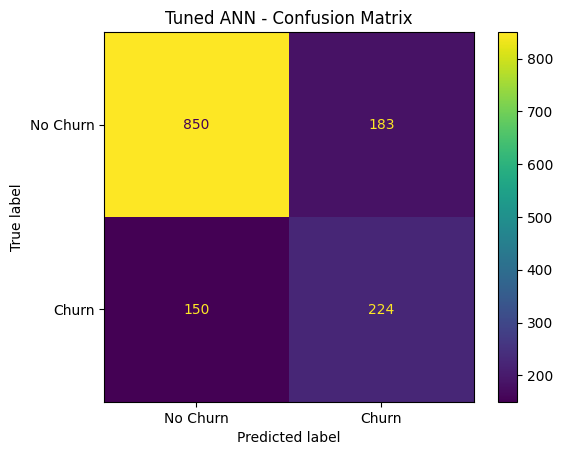

In [53]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Get predicted probabilities
tuned_pred_prob = tuned_ann.predict(X_test_processed)

# Convert probabilities to 0/1 predictions
tuned_pred = (tuned_pred_prob >= 0.5).astype(int).flatten()

# Classification report
print("Tuned ANN Classification Report:")
print(classification_report(y_test, tuned_pred))

# Confusion matrix
tuned_cm = confusion_matrix(y_test, tuned_pred)

print("\nTuned ANN Confusion Matrix:")
print(tuned_cm)

ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Tuned ANN - Confusion Matrix")
plt.show()

### Step 36 — ROC-AUC for Tuned ANN

Tuned ANN ROC-AUC: 0.8020


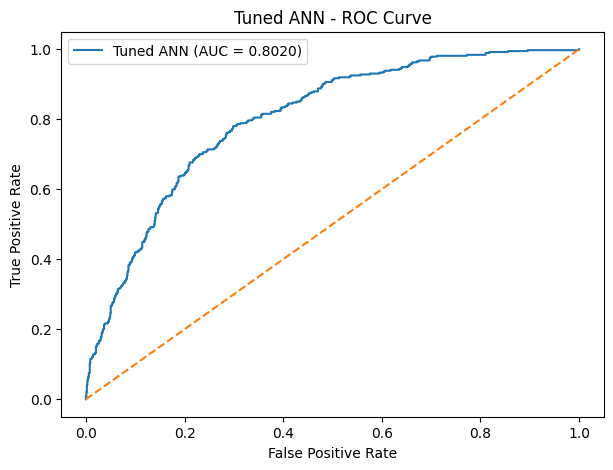

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC-AUC
tuned_auc = roc_auc_score(y_test, tuned_pred_prob)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, tuned_pred_prob)

print(f"Tuned ANN ROC-AUC: {tuned_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Tuned ANN (AUC = {tuned_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Tuned ANN - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#### Compare ANN with traditional Machine Learning algorithms.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Define ML models
ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("ML models created successfully.")

ML models created successfully.


### Step 1 — Train the ML models

In [56]:
# Train all ML models

ml_results = {}

for name, model in ml_models.items():
    print(f"Training {name}...")
    
    model.fit(
        X_train_smote,
        y_train_smote
    )
    
    y_pred = model.predict(X_test_processed)
    
    ml_results[name] = y_pred

print("\nAll ML models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All ML models trained successfully.


### Step 2 — Evaluate the ML models

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ml_metrics = []

for name, y_pred in ml_results.items():

    model = ml_models[name]

    # Get probability for ROC-AUC
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    ml_metrics.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

ml_results_df = pd.DataFrame(ml_metrics)

print(ml_results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.7321     0.4974  0.7781    0.6069   0.8334
1        Decision Tree    0.7399     0.5093  0.5829    0.5436   0.6898
2        Random Forest    0.7719     0.5710  0.5695    0.5703   0.8111
3    Gradient Boosting    0.7669     0.5502  0.6738    0.6058   0.8336


#### Observation: Logistic Regression catches the most churners (77.81% recall), but it also produces more false alarms.Decision Tree is the weakest overall, especially with ROC-AUC of only 0.6898.Random Forest has the highest ML accuracy (77.19%) and best ML precision (57.10%).Gradient Boosting has the best ML ROC-AUC (0.8336) and a strong recall (67.38%).So we cannot simply say Random Forest is the best. It depends on the business objective. For identifying potential churners, Gradient Boosting gives a particularly strong balance.

#### comparison table

In [58]:
# ANN vs ML comparison

comparison = [
    {
        "Model": "Vanilla ANN",
        "Accuracy": ann_test_accuracy,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc
    },
    {
        "Model": "Tuned ANN",
        "Accuracy": tuned_test_accuracy,
        "Precision": precision_score(y_test, tuned_pred),
        "Recall": recall_score(y_test, tuned_pred),
        "F1-Score": f1_score(y_test, tuned_pred),
        "ROC-AUC": tuned_auc
    }
]

# Add ML models
for row in ml_metrics:
    comparison.append(row)

comparison_df = pd.DataFrame(comparison)

print(comparison_df.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0          Vanilla ANN    0.7740     0.5502  0.6738    0.6058   0.8116
1            Tuned ANN    0.7633     0.5504  0.5989    0.5736   0.8020
2  Logistic Regression    0.7321     0.4974  0.7781    0.6069   0.8334
3        Decision Tree    0.7399     0.5093  0.5829    0.5436   0.6898
4        Random Forest    0.7719     0.5710  0.5695    0.5703   0.8111
5    Gradient Boosting    0.7669     0.5502  0.6738    0.6058   0.8336


### Tune the Random Forest

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest parameter combinations
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.9353


### Test the tuned Random Forest

In [60]:
# Best Random Forest model
best_rf = rf_grid.best_estimator_

# Predict on the untouched test set
rf_pred = best_rf.predict(X_test_processed)
rf_prob = best_rf.predict_proba(X_test_processed)[:, 1]

# Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Tuned Random Forest Results")
print("----------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Tuned Random Forest Results
----------------------------
Accuracy : 0.7733
Precision: 0.5707
Recall   : 0.5936
F1-Score : 0.5819
ROC-AUC  : 0.8135

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1033
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407


Confusion Matrix:
[[866 167]
 [152 222]]


### Tune Gradient Boosting

In [61]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(round(gb_grid.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.9224


### Test the tuned Gradient Boosting model

In [62]:
# Get the best Gradient Boosting model
best_gb = gb_grid.best_estimator_

# Predict on the untouched test set
gb_pred = best_gb.predict(X_test_processed)
gb_prob = best_gb.predict_proba(X_test_processed)[:, 1]

# Evaluate
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_auc = roc_auc_score(y_test, gb_prob)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1-Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Tuned Gradient Boosting Results
--------------------------------
Accuracy : 0.7669
Precision: 0.5502
Recall   : 0.6738
F1-Score : 0.6058
ROC-AUC  : 0.8336

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407


Confusion Matrix:
[[827 206]
 [122 252]]


### Create the final comparison table

In [63]:
# Final ANN vs ML comparison

final_comparison = pd.DataFrame([
    {
        "Model": "Vanilla ANN",
        "Accuracy": 0.7740,
        "Precision": 0.5502,
        "Recall": 0.6738,
        "F1-Score": 0.6058,
        "ROC-AUC": 0.8116
    },
    {
        "Model": "Tuned ANN",
        "Accuracy": tuned_test_accuracy,
        "Precision": precision_score(y_test, tuned_pred),
        "Recall": recall_score(y_test, tuned_pred),
        "F1-Score": f1_score(y_test, tuned_pred),
        "ROC-AUC": tuned_auc
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.7321,
        "Precision": 0.4974,
        "Recall": 0.7781,
        "F1-Score": 0.6069,
        "ROC-AUC": 0.8334
    },
    {
        "Model": "Decision Tree",
        "Accuracy": 0.7399,
        "Precision": 0.5093,
        "Recall": 0.5829,
        "F1-Score": 0.5436,
        "ROC-AUC": 0.6898
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.7719,
        "Precision": 0.5710,
        "Recall": 0.5695,
        "F1-Score": 0.5703,
        "ROC-AUC": 0.8111
    },
    {
        "Model": "Gradient Boosting",
        "Accuracy": 0.7669,
        "Precision": 0.5502,
        "Recall": 0.6738,
        "F1-Score": 0.6058,
        "ROC-AUC": 0.8336
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1-Score": rf_f1,
        "ROC-AUC": rf_auc
    },
    {
        "Model": "Tuned Gradient Boosting",
        "Accuracy": gb_accuracy,
        "Precision": gb_precision,
        "Recall": gb_recall,
        "F1-Score": gb_f1,
        "ROC-AUC": gb_auc
    }
])

print("Final ANN vs ML Model Comparison")
print("---------------------------------")
display(final_comparison.round(4))

Final ANN vs ML Model Comparison
---------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Vanilla ANN,0.7740,0.5502,0.6738,0.6058,0.8116
1,Tuned ANN,0.7633,0.5504,0.5989,0.5736,0.8020
2,Logistic Regression,0.7321,0.4974,0.7781,0.6069,0.8334
3,Decision Tree,0.7399,0.5093,0.5829,0.5436,0.6898
4,Random Forest,0.7719,0.5710,0.5695,0.5703,0.8111
5,Gradient Boosting,0.7669,0.5502,0.6738,0.6058,0.8336
6,Tuned Random Forest,0.7733,0.5707,0.5936,0.5819,0.8135
7,Tuned Gradient Boosting,0.7669,0.5502,0.6738,0.6058,0.8336


#### Observation
- Best ANN accuracy: Vanilla ANN — 77.40%.
- Best ML ROC-AUC: Gradient Boosting — 83.36%.
- Best churn recall: Logistic Regression — 77.81%.
- Best F1-score: Logistic Regression 60.69%.
- Tuned ANN actually performed slightly worse than Vanilla ANN on the test set.

### Automatically identify the best models

In [64]:
# Identify the best model for each important metric

print("Best Model by Accuracy:")
best_accuracy = final_comparison.loc[
    final_comparison["Accuracy"].idxmax()
]
print(best_accuracy["Model"], "->", round(best_accuracy["Accuracy"], 4))

print("\nBest Model by Precision:")
best_precision = final_comparison.loc[
    final_comparison["Precision"].idxmax()
]
print(best_precision["Model"], "->", round(best_precision["Precision"], 4))

print("\nBest Model by Recall:")
best_recall = final_comparison.loc[
    final_comparison["Recall"].idxmax()
]
print(best_recall["Model"], "->", round(best_recall["Recall"], 4))

print("\nBest Model by F1-Score:")
best_f1 = final_comparison.loc[
    final_comparison["F1-Score"].idxmax()
]
print(best_f1["Model"], "->", round(best_f1["F1-Score"], 4))

print("\nBest Model by ROC-AUC:")
best_auc = final_comparison.loc[
    final_comparison["ROC-AUC"].idxmax()
]
print(best_auc["Model"], "->", round(best_auc["ROC-AUC"], 4))

Best Model by Accuracy:
Vanilla ANN -> 0.774

Best Model by Precision:
Random Forest -> 0.571

Best Model by Recall:
Logistic Regression -> 0.7781

Best Model by F1-Score:
Logistic Regression -> 0.6069

Best Model by ROC-AUC:
Tuned Gradient Boosting -> 0.8336


## Final Model Evaluation – Observations and Insights

### Model Performance Observations

1. The Vanilla ANN achieved the highest overall test accuracy of 77.40% among the evaluated models.

2. The Tuned ANN achieved a test accuracy of 76.33%, which was slightly lower than the Vanilla ANN. Therefore, hyperparameter tuning did not improve the ANN's test performance in this experiment.

3. Logistic Regression achieved the highest recall of 77.81%. This means it identified the largest proportion of customers who actually churned.

4. Logistic Regression also achieved the highest F1-score of 60.69%, showing a good balance between precision and recall for churn prediction.

5. Random Forest achieved the highest precision of 57.10%, meaning that among the customers predicted as churners, it had the highest proportion of correct churn predictions.

6. Tuned Gradient Boosting achieved the highest ROC-AUC of 83.36%. This indicates that it provided the strongest overall ability to distinguish between customers who churn and customers who do not churn.

7. The traditional machine learning models performed competitively with the ANN models. This shows that ANN is not automatically the best choice for every tabular classification problem.

8. The results demonstrate that model selection should depend on the business objective rather than accuracy alone. For example, if the company wants to identify as many potential churners as possible, recall becomes especially important.

## Business Recommendations

Based on the customer churn prediction results, the following recommendations can be made:

1. Customers identified as high-risk churners should be targeted with retention strategies such as personalized offers, discounts, service upgrades, or improved support.

2. Since Logistic Regression achieved the highest churn recall of 77.81%, it can be considered when the primary business objective is to identify as many potential churners as possible.

3. Tuned Gradient Boosting achieved the highest ROC-AUC of 83.36%, making it a strong candidate when the objective is to obtain better overall separation between churn and non-churn customers.

4. Customer retention campaigns should focus on customers predicted to have a high probability of churn rather than applying the same strategy to all customers.

5. The company should continuously monitor model performance using metrics such as recall, F1-score and ROC-AUC because customer behavior can change over time.

## Conclusion

In this project, we developed different machine learning and ANN models to predict customer churn.

The Vanilla ANN achieved the highest test accuracy of 77.40%. However, the tuned ANN achieved 76.33%, so hyperparameter tuning did not improve the ANN performance on the unseen test data.

Among the machine learning models, Logistic Regression achieved the highest recall of 77.81%. This makes it useful when the main goal is to identify as many potential churn customers as possible.

The Tuned Gradient Boosting model achieved the highest ROC-AUC of 83.36%, showing strong ability to distinguish between churn and non-churn customers.

Overall, the results show that ANN performed competitively on this tabular dataset, but traditional machine learning models also performed very well. The best model should therefore be selected based on the business objective rather than accuracy alone.

For customer retention, Logistic Regression can be considered when identifying potential churners is the main priority, while Tuned Gradient Boosting is a strong choice when overall classification ability measured by ROC-AUC is prioritized.

#### Our Vanilla ANN gave the highest accuracy, Logistic Regression gave the highest recall, and Tuned Gradient Boosting gave the highest ROC-AUC; therefore, model selection depends on the business objective.”`